**PIPELINE STEP 2 of 6 (historical/exploratory -- not required to reproduce the final dataset).**

This is the MI2 pilot notebook for lyric collection: it takes the small pilot sample from `01_MusicBrainz_pilot.ipynb`, fetches lyrics from LRCLIB, and filters to English-language songs, validating the LRCLIB + language-detection approach later used at full scale in `04_collect_dataset.py`. Requires Google Colab (`google.colab.drive`) and is kept for provenance.

In [1]:
import requests
import pandas as pd
import time
import os

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
project_folder = "/content/drive/MyDrive/UVA 2026 27/DS4002/Project 1"

pilot_file = project_folder + "/music_genre_pilot.csv"

lyrics_df = pd.read_csv(pilot_file)

print("Songs loaded:", len(lyrics_df))
lyrics_df.head()

Songs loaded: 60


,recording_id,song_title,artist,artist_id,musicbrainz_tags,target_genre
0,b9c2af67-9f48-4aeb-962f-be99a9ba967e,If You're Gonna Play in Texas (You Gotta Have ...,Alabama,7ac055fa-e357-4890-9098-010b8094a900,"country, country rock, country pop, contempora...",Country
1,f58dd19b-c6b1-4948-adba-87b7f4eec61d,Mountain Music,Alabama,7ac055fa-e357-4890-9098-010b8094a900,"country, country rock, country pop, alternativ...",Country
2,65a6a14c-3793-4e1a-8b22-70c5e929468a,She and I,Alabama,7ac055fa-e357-4890-9098-010b8094a900,"country, country rock, country pop, contempora...",Country
3,dda647bc-59f9-4c0b-b34b-21a472eca788,Strawberry Wine,Deana Carter,49d04262-6389-4f51-829e-d8fd1b8b80fa,"country, country rock, country pop, contempora...",Country
4,61187d8a-2c0e-46c4-8877-b2d136e0325e,That’s How You Know It’s Love,Deana Carter,49d04262-6389-4f51-829e-d8fd1b8b80fa,"country, alternative country, contemporary cou...",Country


In [4]:
lrclib_url = "https://lrclib.net/api/search"

lrclib_headers = {
    "User-Agent": "DS4002GenreProject/1.0 (mmr2ve@virginia.edu)"
}

In [5]:
def get_lrclib_lyrics(song_title, artist_name):

    params = {
        "track_name": song_title,
        "artist_name": artist_name
    }

    response = requests.get(
        lrclib_url,
        params=params,
        headers=lrclib_headers,
        timeout=30
    )

    if response.status_code == 429:
        wait_time = int(
            response.headers.get("Retry-After", 5)
        )

        print(f"Rate limited. Waiting {wait_time} seconds...")
        time.sleep(wait_time)

        response = requests.get(
            lrclib_url,
            params=params,
            headers=lrclib_headers,
            timeout=30
        )

    if response.status_code != 200:
        return None, None, None

    results = response.json()

    if len(results) == 0:
        return None, None, None

    result = results[0]

    return (
        result.get("artistName"),
        result.get("trackName"),
        result.get("plainLyrics")
    )

Single song lyric pull test

In [6]:
test_song = lyrics_df.iloc[0]

matched_artist, matched_title, lyrics = get_lrclib_lyrics(
    test_song["song_title"],
    test_song["artist"]
)

print("Our artist:", test_song["artist"])
print("Our title:", test_song["song_title"])

print()
print("LRCLIB artist:", matched_artist)
print("LRCLIB title:", matched_title)

print()
print("Lyrics found:", lyrics is not None)

Our artist: Alabama
Our title: If You're Gonna Play in Texas (You Gotta Have a Fiddle in the Band)

LRCLIB artist: Alabama
LRCLIB title: If You're Gonna Play in Texas (You Gotta Have a Fiddle in the Band)

Lyrics found: True


Batch all 60 songs

In [7]:
matched_artists = []
matched_titles = []
lyrics_list = []

for i, row in lyrics_df.iterrows():

    matched_artist, matched_title, lyrics = get_lrclib_lyrics(
        row["song_title"],
        row["artist"]
    )

    matched_artists.append(matched_artist)
    matched_titles.append(matched_title)
    lyrics_list.append(lyrics)

    print(
        f"{i + 1}/{len(lyrics_df)}:",
        row["artist"],
        "-",
        row["song_title"],
        "| lyrics:",
        lyrics is not None
    )

    time.sleep(1)

1/60: Alabama - If You're Gonna Play in Texas (You Gotta Have a Fiddle in the Band) | lyrics: True
2/60: Alabama - Mountain Music | lyrics: True
3/60: Alabama - She and I | lyrics: True
4/60: Deana Carter - Strawberry Wine | lyrics: True
5/60: Deana Carter - That’s How You Know It’s Love | lyrics: False
6/60: Deana Carter - To the Other Side | lyrics: True
7/60: Johnny Cash - Engine 143 (mono) | lyrics: True
8/60: Johnny Cash - Chain Gang | lyrics: True
9/60: Johnny Cash - One | lyrics: True
10/60: Waylon Jennings - I May Be Used (but Baby I Ain’t Used Up) | lyrics: True
11/60: Waylon Jennings - Don’t You Think This Outlaw Bit’s Done Got Out of Hand | lyrics: True
12/60: Waylon Jennings - Come With Me | lyrics: False
13/60: Waylon Jennings & Willie Nelson - Put Me on a Train Back to Texas | lyrics: True
14/60: Waylon Jennings & Willie Nelson - Two Old Sidewinders | lyrics: True
15/60: Waylon Jennings & Willie Nelson - The Makin’s of a Song | lyrics: True
16/60: Blue - When Summer’s Gon

In [8]:
lyrics_df["lrclib_artist"] = matched_artists
lyrics_df["lrclib_title"] = matched_titles
lyrics_df["lyrics"] = lyrics_list
lyrics_df["lyrics_found"] = lyrics_df["lyrics"].notna()

In [9]:
print("Lyrics found:", lyrics_df["lyrics_found"].sum())
print("Lyrics missing:", (~lyrics_df["lyrics_found"]).sum())

Lyrics found: 41
Lyrics missing: 19


In [10]:
lyrics_df[
    lyrics_df["lyrics_found"] == False
][
    ["artist", "song_title", "target_genre"]
]

,artist,song_title,target_genre
4,Deana Carter,That’s How You Know It’s Love,Country
11,Waylon Jennings,Come With Me,Country
16,Blue,No Goodbyes,Pop
17,Blue,Where You Want Me,Pop
18,CocoRosie,It Ain’t Easy,Pop
19,CocoRosie,Yesterday,Pop
30,Aurelio Voltaire,Never,Rock
31,Aurelio Voltaire,The Devil and Mr. Jones,Rock
37,FLOW,LOST (Instrumental),Rock
38,FLOW,GET BACK (Anime size),Rock


In [11]:
lyrics_file = project_folder + "/music_genre_pilot_with_lyrics_raw.csv"

lyrics_df.to_csv(
    lyrics_file,
    index=False
)

print("Saved to:", lyrics_file)

Saved to: /content/drive/MyDrive/UVA 2026 27/DS4002/Project 1/music_genre_pilot_with_lyrics_raw.csv


In [12]:
!pip install langdetect -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 13.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [13]:
from langdetect import detect, LangDetectException

def detect_language(text):
    if pd.isna(text) or not str(text).strip():
        return None

    try:
        return detect(text)
    except LangDetectException:
        return None

lyrics_df["language"] = lyrics_df["lyrics"].apply(detect_language)

In [14]:
lyrics_df["language"].value_counts(dropna=False)

,count
language,
en,33
None,19
ja,4
sw,2
hr,1
ru,1


In [15]:
usable = lyrics_df[
    (lyrics_df["lyrics_found"] == True) &
    (lyrics_df["language"] == "en")
]

usable["target_genre"].value_counts()

,count
target_genre,
Country,13
Pop,8
Hip-Hop/Rap,8
Rock,4


In [16]:
non_english_found = lyrics_df[
    (lyrics_df["lyrics_found"] == True) &
    (lyrics_df["language"] != "en")
].copy()

non_english_found["word_count"] = (
    non_english_found["lyrics"]
    .fillna("")
    .str.split()
    .str.len()
)

non_english_found[
    [
        "artist",
        "song_title",
        "target_genre",
        "language",
        "word_count"
    ]
]

,artist,song_title,target_genre,language,word_count
27,YUI,We will go,Pop,ja,63
28,YUI,Find me,Pop,ja,56
29,YUI,Laugh away,Pop,ja,93
36,FLOW,GET BACK (English ver.),Rock,ja,64
39,MALICE MIZER,Le ciel 〜空白の彼方へ〜,Rock,sw,122
40,MALICE MIZER,N・p・s N・g・s [N‐type],Rock,hr,71
41,MALICE MIZER,ILLUMINATI [P‐type],Rock,sw,170
44,Пикник,Побежать бы за леса-горы,Rock,ru,78


In [19]:
import pandas as pd
from google.colab import drive

drive.mount("/content/drive")

project_folder = "/content/drive/MyDrive/UVA 2026 27/DS4002/Project 1"

raw_lyrics_file = project_folder + "/music_genre_pilot_with_lyrics_raw.csv"

lyrics_df = pd.read_csv(raw_lyrics_file)

print("Songs loaded:", len(lyrics_df))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Songs loaded: 60


In [21]:
!pip install langdetect -q

In [22]:
from langdetect import detect, LangDetectException

def detect_language(text):
    if pd.isna(text) or not str(text).strip():
        return None

    try:
        return detect(text)
    except LangDetectException:
        return None

lyrics_df["language"] = lyrics_df["lyrics"].apply(detect_language)

In [24]:
from langdetect import detect, LangDetectException, DetectorFactory

DetectorFactory.seed = 4002

def detect_language(text):
    if pd.isna(text) or not str(text).strip():
        return None

    try:
        return detect(text)
    except LangDetectException:
        return None

lyrics_df["language"] = lyrics_df["lyrics"].apply(detect_language)

In [27]:
lyrics_df["language"].value_counts(dropna=False)

,count
language,
en,33
None,19
ja,4
sw,1
hr,1
id,1
ru,1


In [26]:
clean_pilot = lyrics_df[
    (lyrics_df["lyrics_found"] == True) &
    (lyrics_df["language"] == "en")
].copy()

print("Usable songs:", len(clean_pilot))
print(clean_pilot["target_genre"].value_counts())

Usable songs: 33
target_genre
Country        13
Pop             8
Hip-Hop/Rap     8
Rock            4
Name: count, dtype: int64


In [20]:
clean_pilot["word_count"] = (
    clean_pilot["lyrics"]
    .fillna("")
    .str.split()
    .str.len()
)

clean_pilot[
    ["artist", "song_title", "target_genre", "word_count"]
].head()

NameError: name 'clean_pilot' is not defined

In [28]:
missing_now = lyrics_df[lyrics_df["lyrics"].isna()].copy()

print("Lyrics currently found:", lyrics_df["lyrics"].notna().sum())
print("Lyrics currently missing:", lyrics_df["lyrics"].isna().sum())

missing_now[
    ["artist", "song_title", "target_genre"]
]

Lyrics currently found: 41
Lyrics currently missing: 19


,artist,song_title,target_genre
4,Deana Carter,That’s How You Know It’s Love,Country
11,Waylon Jennings,Come With Me,Country
16,Blue,No Goodbyes,Pop
17,Blue,Where You Want Me,Pop
18,CocoRosie,It Ain’t Easy,Pop
19,CocoRosie,Yesterday,Pop
30,Aurelio Voltaire,Never,Rock
31,Aurelio Voltaire,The Devil and Mr. Jones,Rock
37,FLOW,LOST (Instrumental),Rock
38,FLOW,GET BACK (Anime size),Rock


In [29]:
for i in lyrics_df[lyrics_df["lyrics"].isna()].index:

    artist = lyrics_df.loc[i, "artist"]
    title = lyrics_df.loc[i, "song_title"]

    print("Retrying:", artist, "-", title)

    matched_artist, matched_title, lyrics = get_lrclib_lyrics(
        title,
        artist
    )

    if lyrics is not None:
        lyrics_df.loc[i, "lrclib_artist"] = matched_artist
        lyrics_df.loc[i, "lrclib_title"] = matched_title
        lyrics_df.loc[i, "lyrics"] = lyrics

        print("  FOUND")
    else:
        print("  still missing")

    time.sleep(2)

Retrying: Deana Carter - That’s How You Know It’s Love
  FOUND
Retrying: Waylon Jennings - Come With Me
  FOUND
Retrying: Blue - No Goodbyes
  FOUND
Retrying: Blue - Where You Want Me
  FOUND
Retrying: CocoRosie - It Ain’t Easy
  FOUND
Retrying: CocoRosie - Yesterday
  FOUND
Retrying: Aurelio Voltaire - Never
  FOUND
Retrying: Aurelio Voltaire - The Devil and Mr. Jones
  FOUND
Retrying: FLOW - LOST (Instrumental)
  still missing
Retrying: FLOW - GET BACK (Anime size)
  still missing
Retrying: Пикник - Apokalips
  still missing
Retrying: Пикник - Всё остальное — дым
  still missing
Retrying: Eyedea & Abilities - This Story
  FOUND
Retrying: Lil Wayne - Rider
  still missing
Retrying: Missy Misdemeanor Elliott - Bite Our Style (interlude)
  FOUND
Retrying: People Under the Stairs - Get Drunk
  FOUND
Retrying: People Under the Stairs - Fredly Advice
  still missing
Retrying: People Under the Stairs - The Cat
  FOUND
Retrying: Yung Joc - BYOB
  FOUND


In [30]:
lyrics_df["lyrics_found"] = lyrics_df["lyrics"].notna()

print("Lyrics found:", lyrics_df["lyrics_found"].sum())
print("Lyrics missing:", (~lyrics_df["lyrics_found"]).sum())

Lyrics found: 54
Lyrics missing: 6


In [31]:
matched_artist, matched_title, lyrics = get_lrclib_lyrics(
    "Fredly Advice",
    "People Under the Stairs"
)

if lyrics is not None:
    lyrics_df.loc[55, "lrclib_artist"] = matched_artist
    lyrics_df.loc[55, "lrclib_title"] = matched_title
    lyrics_df.loc[55, "lyrics"] = lyrics
    print("FOUND")
else:
    print("Still missing")

FOUND


In [32]:
lyrics_df["lyrics_found"] = lyrics_df["lyrics"].notna()

print("Lyrics found:", lyrics_df["lyrics_found"].sum())
print("Lyrics missing:", (~lyrics_df["lyrics_found"]).sum())

Lyrics found: 55
Lyrics missing: 5


In [33]:
repaired_file = project_folder + "/music_genre_pilot_with_lyrics_repaired.csv"

lyrics_df.to_csv(
    repaired_file,
    index=False
)

print("Saved repaired dataset to:")
print(repaired_file)

Saved repaired dataset to:
/content/drive/MyDrive/UVA 2026 27/DS4002/Project 1/music_genre_pilot_with_lyrics_repaired.csv


In [34]:
from langdetect import detect, LangDetectException, DetectorFactory

DetectorFactory.seed = 4002

def detect_language(text):
    if pd.isna(text) or not str(text).strip():
        return None

    try:
        return detect(text)
    except LangDetectException:
        return None

lyrics_df["language"] = lyrics_df["lyrics"].apply(detect_language)

lyrics_df["language"].value_counts(dropna=False)

,count
language,
en,47
None,5
ja,4
sw,1
hr,1
id,1
ru,1


In [35]:
clean_pilot = lyrics_df[
    (lyrics_df["lyrics_found"] == True) &
    (lyrics_df["language"] == "en")
].copy()

print("Usable songs:", len(clean_pilot))
print(clean_pilot["target_genre"].value_counts())

Usable songs: 47
target_genre
Country        15
Hip-Hop/Rap    14
Pop            12
Rock            6
Name: count, dtype: int64


In [36]:
clean_pilot["word_count"] = (
    clean_pilot["lyrics"]
    .fillna("")
    .str.split()
    .str.len()
)

clean_pilot[
    ["artist", "song_title", "target_genre", "word_count"]
].head()

,artist,song_title,target_genre,word_count
0,Alabama,If You're Gonna Play in Texas (You Gotta Have ...,Country,339
1,Alabama,Mountain Music,Country,193
2,Alabama,She and I,Country,385
3,Deana Carter,Strawberry Wine,Country,244
4,Deana Carter,That’s How You Know It’s Love,Country,233


In [37]:
clean_pilot.groupby("target_genre")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
target_genre,,,,,,,,
Country,15.0,259.600000,65.181943,182.0,212.00,234.0,303.50,385.0
Hip-Hop/Rap,14.0,414.071429,187.458494,68.0,335.00,406.0,534.25,724.0
Pop,12.0,249.500000,110.971331,60.0,206.75,252.0,315.25,465.0
Rock,6.0,306.333333,118.688949,164.0,245.75,268.0,376.50,487.0


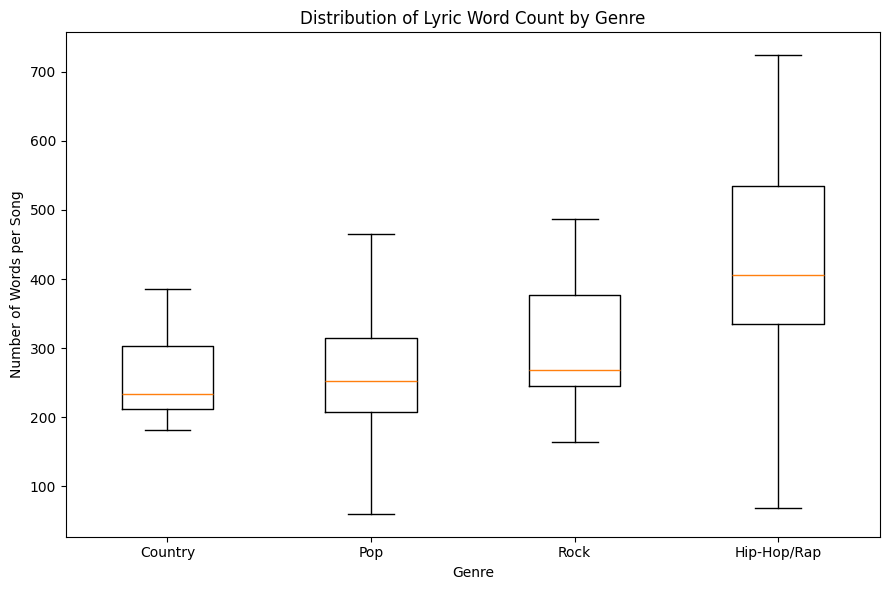

In [38]:
import matplotlib.pyplot as plt

genre_order = [
    "Country",
    "Pop",
    "Rock",
    "Hip-Hop/Rap"
]

plot_data = [
    clean_pilot.loc[
        clean_pilot["target_genre"] == genre,
        "word_count"
    ]
    for genre in genre_order
]

plt.figure(figsize=(9, 6))

plt.boxplot(
    plot_data,
    tick_labels=genre_order
)

plt.title("Distribution of Lyric Word Count by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Words per Song")

plt.tight_layout()
plt.show()

In [39]:
figures_folder = project_folder + "/figures"

import os
os.makedirs(figures_folder, exist_ok=True)

In [40]:
plt.savefig(
    figures_folder + "/lyric_word_count_by_genre.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

Import the TF-IDF tool

In [42]:
tfidf = TfidfVectorizer(
    stop_words="english",
    lowercase=True,
    min_df=2
)

tfidf_matrix = tfidf.fit_transform(clean_pilot["lyrics"])

feature_names = tfidf.get_feature_names_out()

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names,
    index=clean_pilot.index
)

print("Number of TF-IDF terms:", len(feature_names))

Number of TF-IDF terms: 538


Transform lyrics

In [43]:
genre_tfidf = {}

for genre in clean_pilot["target_genre"].unique():

    genre_indices = clean_pilot[
        clean_pilot["target_genre"] == genre
    ].index

    genre_scores = tfidf_df.loc[genre_indices].mean()

    genre_tfidf[genre] = (
        genre_scores
        .sort_values(ascending=False)
        .head(10)
    )

calcutlate tf-idf average

In [44]:
for genre, scores in genre_tfidf.items():
    print("\n", genre)
    print(scores)


 Country
ain      0.111487
love     0.109975
ve       0.075222
got      0.072957
play     0.069585
know     0.067431
texas    0.065516
like     0.061182
don      0.059429
old      0.058045
dtype: float64

 Pop
love    0.117628
ll      0.116711
oh      0.092781
baby    0.086598
day     0.082427
got     0.080017
road    0.064141
know    0.060504
life    0.059364
long    0.058970
dtype: float64

 Rock
turn       0.211999
cold       0.146070
tonight    0.115998
hell       0.090306
dear       0.088132
mr         0.086438
black      0.084745
want       0.072575
like       0.058144
sea        0.056593
dtype: float64

 Hip-Hop/Rap
just       0.086355
man        0.084827
alright    0.073277
got        0.072982
like       0.072670
nigga      0.068437
make       0.065785
la         0.065727
won        0.064674
ooh        0.064636
dtype: float64


Getting rid of tokenizer leftovers

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

extra_stop_words = {
    "ain", "ll", "ve", "don", "won",
    "oh", "ooh", "la"
}

custom_stop_words = list(
    ENGLISH_STOP_WORDS.union(extra_stop_words)
)

tfidf = TfidfVectorizer(
    stop_words=custom_stop_words,
    lowercase=True,
    min_df=2
)

tfidf_matrix = tfidf.fit_transform(clean_pilot["lyrics"])

feature_names = tfidf.get_feature_names_out()

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names,
    index=clean_pilot.index
)

print("Number of TF-IDF terms:", len(feature_names))

Number of TF-IDF terms: 530


rerunning to get genre averages

In [46]:
genre_tfidf = {}

for genre in clean_pilot["target_genre"].unique():

    genre_indices = clean_pilot[
        clean_pilot["target_genre"] == genre
    ].index

    genre_scores = tfidf_df.loc[genre_indices].mean()

    genre_tfidf[genre] = (
        genre_scores
        .sort_values(ascending=False)
        .head(10)
    )

In [47]:
for genre, scores in genre_tfidf.items():
    print("\n", genre)
    print(scores)


 Country
love     0.115224
got      0.077846
play     0.071818
know     0.071590
texas    0.065936
like     0.063039
old      0.061697
just     0.055881
think    0.052374
let      0.050228
dtype: float64

 Pop
love    0.119933
baby    0.096331
got     0.094580
day     0.082427
road    0.066497
know    0.065914
easy    0.063109
life    0.062424
dark    0.061767
long    0.058970
dtype: float64

 Rock
turn       0.212129
cold       0.146070
tonight    0.118394
hell       0.090541
dear       0.088413
mr         0.086557
black      0.084834
want       0.072835
like       0.058268
sea        0.056830
dtype: float64

 Hip-Hop/Rap
just       0.087298
man        0.085843
make       0.077312
got        0.075275
like       0.075070
alright    0.073405
nigga      0.069077
thing      0.066179
know       0.064476
bitch      0.059393
dtype: float64


In [48]:
display_blocklist = {
    "nigga",
    "bitch"
}

In [49]:
genre_tfidf_display = {}

for genre in clean_pilot["target_genre"].unique():

    genre_indices = clean_pilot[
        clean_pilot["target_genre"] == genre
    ].index

    genre_scores = tfidf_df.loc[genre_indices].mean()

    genre_scores = genre_scores[
        ~genre_scores.index.isin(display_blocklist)
    ]

    genre_tfidf_display[genre] = (
        genre_scores
        .sort_values(ascending=False)
        .head(10)
    )

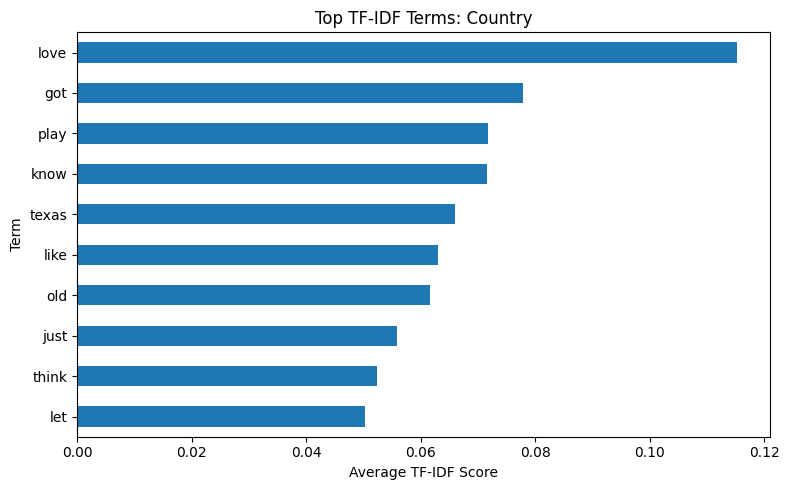

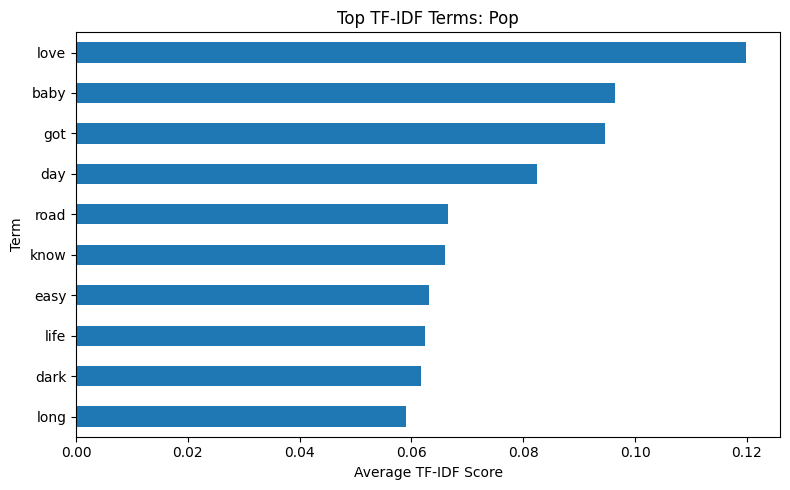

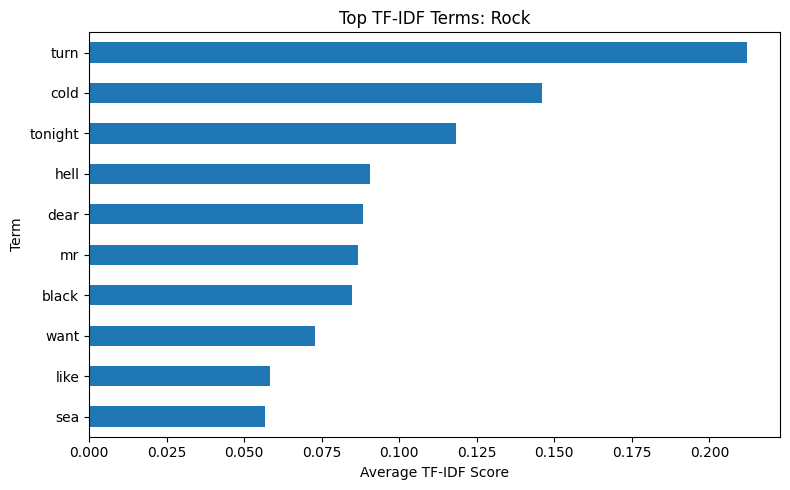

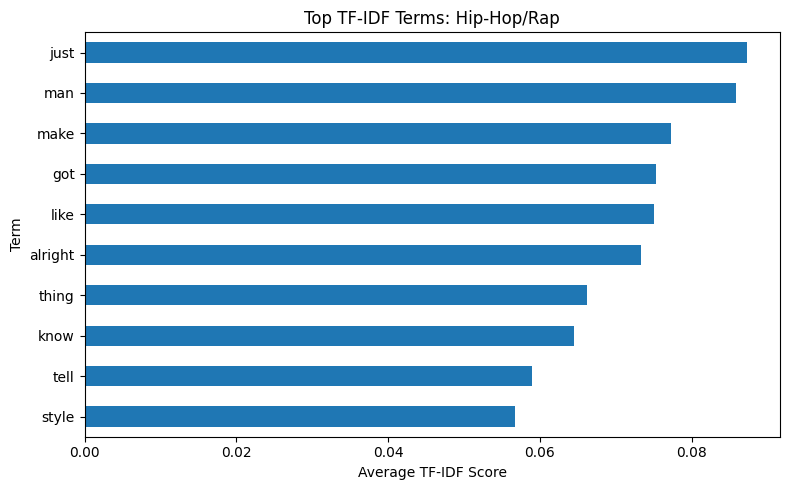

In [50]:
import matplotlib.pyplot as plt

for genre, scores in genre_tfidf_display.items():

    plt.figure(figsize=(8, 5))

    scores.sort_values().plot(
        kind="barh"
    )

    plt.title(f"Top TF-IDF Terms: {genre}")
    plt.xlabel("Average TF-IDF Score")
    plt.ylabel("Term")

    plt.tight_layout()
    plt.show()

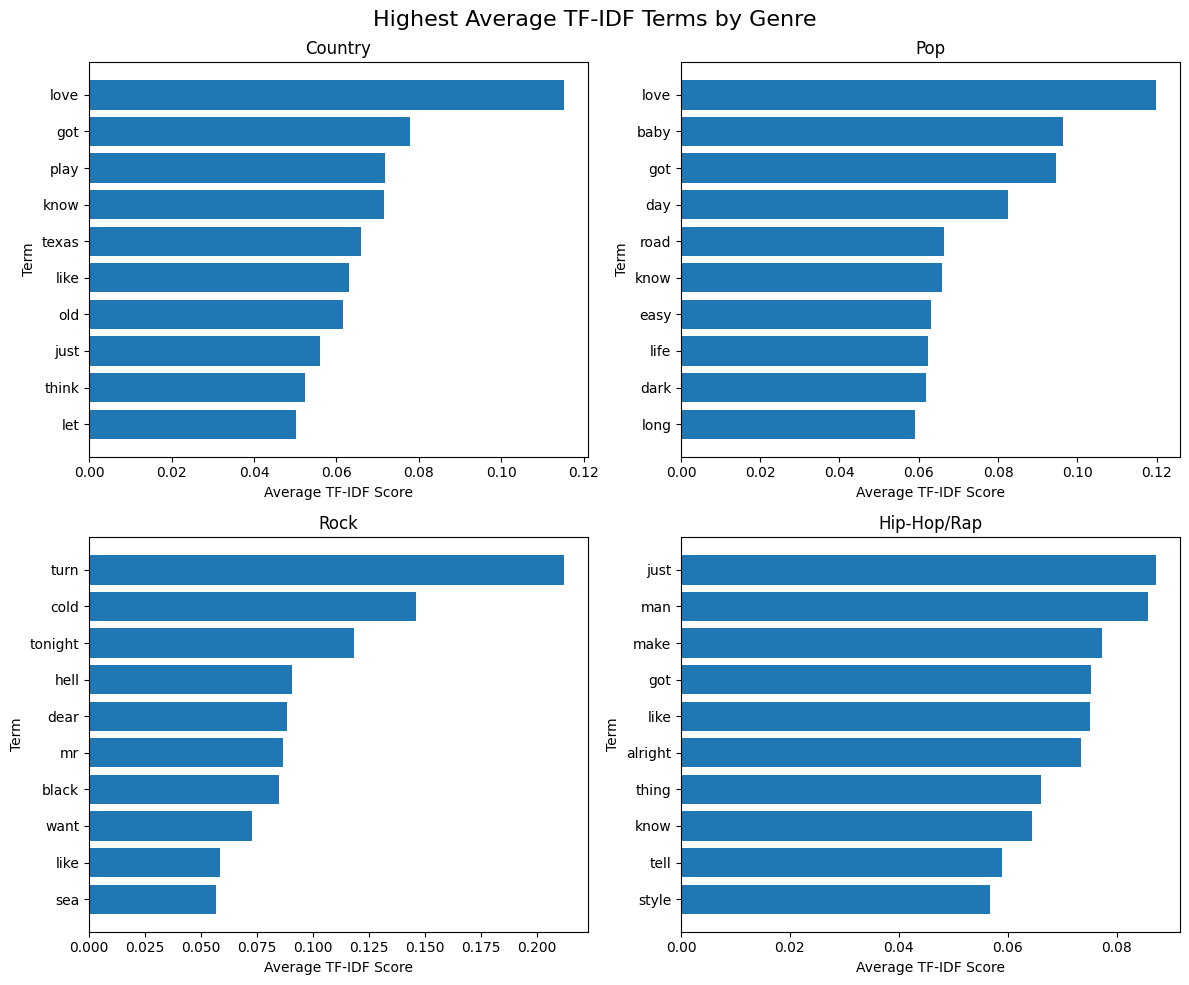

In [51]:
import matplotlib.pyplot as plt

genre_order = [
    "Country",
    "Pop",
    "Rock",
    "Hip-Hop/Rap"
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10)
)

axes = axes.flatten()

for ax, genre in zip(axes, genre_order):

    scores = genre_tfidf_display[genre].sort_values()

    ax.barh(
        scores.index,
        scores.values
    )

    ax.set_title(genre)
    ax.set_xlabel("Average TF-IDF Score")
    ax.set_ylabel("Term")

fig.suptitle(
    "Highest Average TF-IDF Terms by Genre",
    fontsize=16
)

plt.tight_layout()

plt.show()

In [52]:
figures_folder = project_folder + "/figures"

import os
os.makedirs(figures_folder, exist_ok=True)

fig.savefig(
    figures_folder + "/tfidf_terms_by_genre.png",
    dpi=300,
    bbox_inches="tight"
)

print("TF-IDF figure saved.")

TF-IDF figure saved.


In [53]:
clean_file = project_folder + "/music_genre_pilot_english_lyrics.csv"

clean_pilot.to_csv(
    clean_file,
    index=False
)

print("Clean dataset saved:")
print(clean_file)

Clean dataset saved:
/content/drive/MyDrive/UVA 2026 27/DS4002/Project 1/music_genre_pilot_english_lyrics.csv


In [54]:
figures_folder = project_folder + "/figures"

import os
os.makedirs(figures_folder, exist_ok=True)

fig.savefig(
    figures_folder + "/tfidf_terms_by_genre.png",
    dpi=300,
    bbox_inches="tight"
)

print("TF-IDF figure saved.")

TF-IDF figure saved.


In [55]:
clean_file = project_folder + "/music_genre_pilot_english_lyrics.csv"

clean_pilot.to_csv(
    clean_file,
    index=False
)

print("Clean dataset saved:")
print(clean_file)

Clean dataset saved:
/content/drive/MyDrive/UVA 2026 27/DS4002/Project 1/music_genre_pilot_english_lyrics.csv


In [56]:
genre_summary = (
    clean_pilot
    .groupby("target_genre")
    .agg(
        songs=("song_title", "count"),
        artists=("artist", "nunique"),
        mean_word_count=("word_count", "mean"),
        median_word_count=("word_count", "median"),
        min_word_count=("word_count", "min"),
        max_word_count=("word_count", "max")
    )
    .round(1)
)

genre_summary

,songs,artists,mean_word_count,median_word_count,min_word_count,max_word_count
target_genre,,,,,,
Country,15,5,259.6,234.0,182,385
Hip-Hop/Rap,14,5,414.1,406.0,68,724
Pop,12,4,249.5,252.0,60,465
Rock,6,2,306.3,268.0,164,487
